# 07 — Cross-method agreement and consensus

**Notebook 7 of 9 — Drosophila book-chapter production pipeline**

**Purpose:** Quantify cross-method agreement and construct the primary k = 2 consensus and secondary k = 3 exact-signature interfaces.

**Primary inputs:** `data/processed/k2_cluster_assignments_dtw.csv`; `data/processed/k3_cluster_assignments_dtw.csv`; `data/processed/k2_cluster_assignments_pca.csv`; `data/processed/k3_cluster_assignments_pca.csv`; `data/processed/k2_cluster_assignments_nmf.csv`; `data/processed/k3_cluster_assignments_nmf.csv`

**Primary outputs:** `data/processed/k2_consensus_assignments.csv`; `data/processed/k2_unanimous_consensus_cells.csv`; `data/processed/k3_stability_qualified_signature_summary.csv`; `data/processed/k3_cluster_assignments_with_stability_qualified_signatures.csv`; `figures/Book_Chapter_Fig_3.png`; `figures/Book_Chapter_Fig_3.tiff`

**Manuscript role:** Cross-method agreement and consensus results; produces Book Chapter Figure 3 and the membership interfaces characterized in Notebooks 08 and 09.

**Project authors:** Tim Rogalsky, Nicolas Malagon, Lia Campbell-Enns, Matthaeus Dyck

**Reproducibility:** Designed for fresh-kernel execution in production order 01→09 using repository-relative paths. It consumes only the six explicit assignment interfaces written by Notebooks 02, 05, and 06 and requires no private, diagnostic, or obsolete provenance artifact.

The complete six-stream audit uses DW, DK, PH, PK, NH, and NK at both resolutions. The strict five-stream consensus for k = 2 and the stability-qualified strict five-stream set for k = 3 use DW, DK, PK, NH, and NK; PH remains in the complete audits but is excluded from the strict sets because of PCA-Ward dimensional sensitivity. Pipeline-local labels are not permuted.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, rand_score
from IPython.display import display

PROCESSED_DIR = Path('data/processed')
FIGURE_DIR = Path('figures')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ASSIGNMENT_FILES = {
    'k2_dtw': (PROCESSED_DIR / 'k2_cluster_assignments_dtw.csv', ['Cell_Name', 'K2_DW', 'K2_DK']),
    'k3_dtw': (PROCESSED_DIR / 'k3_cluster_assignments_dtw.csv', ['Cell_Name', 'K3_DW', 'K3_DK']),
    'k2_pca': (PROCESSED_DIR / 'k2_cluster_assignments_pca.csv', ['Cell_Name', 'K2_PH', 'K2_PK']),
    'k3_pca': (PROCESSED_DIR / 'k3_cluster_assignments_pca.csv', ['Cell_Name', 'K3_PH', 'K3_PK']),
    'k2_nmf': (PROCESSED_DIR / 'k2_cluster_assignments_nmf.csv', ['Cell_Name', 'K2_NH', 'K2_NK']),
    'k3_nmf': (PROCESSED_DIR / 'k3_cluster_assignments_nmf.csv', ['Cell_Name', 'K3_NH', 'K3_NK']),
}
K2_COLUMNS = ['K2_DW', 'K2_DK', 'K2_PH', 'K2_PK', 'K2_NH', 'K2_NK']
K2_LABELS = ['DW', 'DK', 'PH', 'PK', 'NH', 'NK']
K2_CONSENSUS_COLUMNS = ['K2_DW', 'K2_DK', 'K2_PK', 'K2_NH', 'K2_NK']
K2_CONSENSUS_LABELS = ['DW', 'DK', 'PK', 'NH', 'NK']
K3_COLUMNS = ['K3_DW', 'K3_DK', 'K3_PH', 'K3_PK', 'K3_NH', 'K3_NK']
K3_LABELS = ['DW', 'DK', 'PH', 'PK', 'NH', 'NK']
K3_STRICT_COLUMNS = ['K3_DW', 'K3_DK', 'K3_PK', 'K3_NH', 'K3_NK']
K3_STRICT_LABELS = ['DW', 'DK', 'PK', 'NH', 'NK']
METRICS = {'RI': rand_score, 'NMI': normalized_mutual_info_score, 'ARI': adjusted_rand_score}

def agreement_matrices(assignments, columns, labels):
    matrices = {}
    for metric_name, metric in METRICS.items():
        values = np.empty((len(columns), len(columns)), dtype=float)
        for i, left in enumerate(columns):
            for j, right in enumerate(columns):
                values[i, j] = metric(assignments[left], assignments[right])
        matrix = pd.DataFrame(values, index=labels, columns=labels)
        matrix.index.name = 'Pipeline'
        assert matrix.shape == (len(columns), len(columns))
        assert not matrix.isna().any().any()
        np.testing.assert_allclose(values, values.T, rtol=0, atol=1e-12)
        np.testing.assert_allclose(np.diag(values), 1.0, rtol=0, atol=1e-12)
        matrices[metric_name] = matrix
    return matrices


## Load and validate explicit production assignments

Every file must contain the exact schema, 108 unique cells, complete assignments, and the same deterministic Cell_Name sequence. Concatenation occurs only after the row-order identity assertion.

In [2]:
assignment_tables = {}
reference_cells = None
for key, (path, expected_columns) in ASSIGNMENT_FILES.items():
    table = pd.read_csv(path)
    assert table.columns.tolist() == expected_columns, f'{path}: unexpected schema {table.columns.tolist()}'
    assert len(table) == 108, f'{path}: expected 108 rows, found {len(table)}'
    assert table['Cell_Name'].nunique() == 108 and table['Cell_Name'].is_unique
    assert not table.isna().any().any(), f'{path}: missing values found'
    cells = table['Cell_Name'].tolist()
    if reference_cells is None:
        reference_cells = cells
    else:
        assert set(cells) == set(reference_cells), f'{path}: Cell_Name set differs'
        assert cells == reference_cells, f'{path}: Cell_Name order differs'
    assignment_tables[key] = table
    print(f'{path}: columns={expected_columns}; rows=108; unique cells=108; complete/order PASS')

k2_assignments = pd.DataFrame({'Cell_Name': reference_cells})
for key in ['k2_dtw', 'k2_pca', 'k2_nmf']:
    k2_assignments = pd.concat([k2_assignments, assignment_tables[key].drop(columns='Cell_Name')], axis=1)
k3_assignments = pd.DataFrame({'Cell_Name': reference_cells})
for key in ['k3_dtw', 'k3_pca', 'k3_nmf']:
    k3_assignments = pd.concat([k3_assignments, assignment_tables[key].drop(columns='Cell_Name')], axis=1)

assert k2_assignments.columns.tolist() == ['Cell_Name', *K2_COLUMNS]
assert k3_assignments.columns.tolist() == ['Cell_Name', *K3_COLUMNS]
for column in K2_COLUMNS:
    assert set(k2_assignments[column]) == {1, 2}, f'{column}: expected labels 1/2'
assert set(k3_assignments['K3_DW'].astype(str)) == {'1', '2a', '2b'}
assert set(k3_assignments['K3_DK']) == {0, 1, 2}, 'K3_DK: expected native labels 0/1/2'
for column in ['K3_PH', 'K3_PK', 'K3_NH', 'K3_NK']:
    assert set(k3_assignments[column]) == {1, 2, 3}, f'{column}: expected labels 1/2/3'
print('All six explicit inputs share the same 108-cell set and identical deterministic row order.')


data\processed\k2_cluster_assignments_dtw.csv: columns=['Cell_Name', 'K2_DW', 'K2_DK']; rows=108; unique cells=108; complete/order PASS
data\processed\k3_cluster_assignments_dtw.csv: columns=['Cell_Name', 'K3_DW', 'K3_DK']; rows=108; unique cells=108; complete/order PASS
data\processed\k2_cluster_assignments_pca.csv: columns=['Cell_Name', 'K2_PH', 'K2_PK']; rows=108; unique cells=108; complete/order PASS
data\processed\k3_cluster_assignments_pca.csv: columns=['Cell_Name', 'K3_PH', 'K3_PK']; rows=108; unique cells=108; complete/order PASS
data\processed\k2_cluster_assignments_nmf.csv: columns=['Cell_Name', 'K2_NH', 'K2_NK']; rows=108; unique cells=108; complete/order PASS
data\processed\k3_cluster_assignments_nmf.csv: columns=['Cell_Name', 'K3_NH', 'K3_NK']; rows=108; unique cells=108; complete/order PASS
All six explicit inputs share the same 108-cell set and identical deterministic row order.


## Primary k=2: full six-pipeline agreement audit

RI, NMI, and ARI are calculated directly from the untouched local assignments in the fixed order DW, DK, PH, PK, NH, NK. All six production pipelines, including PH, remain visible in this complete pairwise audit.

In [3]:
k2_matrices = agreement_matrices(k2_assignments, K2_COLUMNS, K2_LABELS)
expected_k2 = {
    'RI': np.array([
        [1.0, 0.8940809968847352, 0.719626168224299, 0.8615437867774316, 0.7862582208376601, 0.8303911388023537],
        [0.8940809968847352, 1.0, 0.6510903426791277, 0.8303911388023537, 0.7862582208376601, 0.7722395292488751],
        [0.719626168224299, 0.6510903426791277, 1.0, 0.6310141917618554, 0.7073381793007961, 0.7452405676704742],
        [0.8615437867774316, 0.8303911388023537, 0.6310141917618554, 1.0, 0.8153340256143995, 0.8303911388023537],
        [0.7862582208376601, 0.7862582208376601, 0.7073381793007961, 0.8153340256143995, 1.0, 0.9108688127379716],
        [0.8303911388023537, 0.7722395292488751, 0.7452405676704742, 0.8303911388023537, 0.9108688127379716, 1.0],
    ]),
    'NMI': np.array([
        [1.0, 0.7274904500196255, 0.3200588314886567, 0.6715640166173024, 0.44858109259657025, 0.523533565484495],
        [0.7274904500196255, 1.0, 0.24729984182289094, 0.5423279795749544, 0.44836827156276743, 0.422421315994413],
        [0.3200588314886567, 0.24729984182289094, 1.0, 0.22765112034430465, 0.40412472267226573, 0.44847712304740406],
        [0.6715640166173024, 0.5423279795749544, 0.22765112034430465, 1.0, 0.5129187640969678, 0.558222646606527],
        [0.44858109259657025, 0.44836827156276743, 0.40412472267226573, 0.5129187640969678, 1.0, 0.726354343725213],
        [0.523533565484495, 0.422421315994413, 0.44847712304740406, 0.558222646606527, 0.726354343725213, 1.0],
    ]),
    'ARI': np.array([
        [1.0, 0.786549875629038, 0.40945621084327927, 0.7216320513376404, 0.568700002067098, 0.656219264310537],
        [0.786549875629038, 1.0, 0.285854979204269, 0.6599767394603382, 0.570795679320436, 0.5417230785253072],
        [0.40945621084327927, 0.285854979204269, 1.0, 0.25016106200120086, 0.39856802702621846, 0.4691544434857636],
        [0.7216320513376404, 0.6599767394603382, 0.25016106200120086, 1.0, 0.6296400823966393, 0.6593640769760521],
        [0.568700002067098, 0.570795679320436, 0.39856802702621846, 0.6296400823966393, 1.0, 0.8204727231262929],
        [0.656219264310537, 0.5417230785253072, 0.4691544434857636, 0.6593640769760521, 0.8204727231262929, 1.0],
    ]),
}
for metric_name, matrix in k2_matrices.items():
    np.testing.assert_allclose(matrix.to_numpy(), expected_k2[metric_name], rtol=0, atol=1e-12)
    matrix.to_csv(PROCESSED_DIR / f'k2_cluster_agreement_{metric_name.lower()}_matrix.csv', index_label='Pipeline')
    print(f'k=2 {metric_name}:')
    display(matrix.round(6))

within_method_targets = {
    ('DW', 'DK'): (0.8940809968847352, 0.7274904500196255, 0.786549875629038),
    ('PH', 'PK'): (0.6310141917618554, 0.22765112034430465, 0.25016106200120086),
    ('NH', 'NK'): (0.9108688127379716, 0.726354343725213, 0.8204727231262929),
}
for pair, targets in within_method_targets.items():
    observed = tuple(k2_matrices[name].loc[pair[0], pair[1]] for name in ['RI', 'NMI', 'ARI'])
    np.testing.assert_allclose(observed, targets, rtol=0, atol=1e-12)
    print(f'{pair[0]} vs {pair[1]}: RI={observed[0]:.15f}, NMI={observed[1]:.15f}, ARI={observed[2]:.15f}')


k=2 RI:


,DW,DK,PH,PK,NH,NK
Pipeline,,,,,,
DW,1.000000,0.894081,0.719626,0.861544,0.786258,0.830391
DK,0.894081,1.000000,0.651090,0.830391,0.786258,0.772240
PH,0.719626,0.651090,1.000000,0.631014,0.707338,0.745241
PK,0.861544,0.830391,0.631014,1.000000,0.815334,0.830391
NH,0.786258,0.786258,0.707338,0.815334,1.000000,0.910869
NK,0.830391,0.772240,0.745241,0.830391,0.910869,1.000000


k=2 NMI:


,DW,DK,PH,PK,NH,NK
Pipeline,,,,,,
DW,1.000000,0.727490,0.320059,0.671564,0.448581,0.523534
DK,0.727490,1.000000,0.247300,0.542328,0.448368,0.422421
PH,0.320059,0.247300,1.000000,0.227651,0.404125,0.448477
PK,0.671564,0.542328,0.227651,1.000000,0.512919,0.558223
NH,0.448581,0.448368,0.404125,0.512919,1.000000,0.726354
NK,0.523534,0.422421,0.448477,0.558223,0.726354,1.000000


k=2 ARI:


,DW,DK,PH,PK,NH,NK
Pipeline,,,,,,
DW,1.000000,0.786550,0.409456,0.721632,0.568700,0.656219
DK,0.786550,1.000000,0.285855,0.659977,0.570796,0.541723
PH,0.409456,0.285855,1.000000,0.250161,0.398568,0.469154
PK,0.721632,0.659977,0.250161,1.000000,0.629640,0.659364
NH,0.568700,0.570796,0.398568,0.629640,1.000000,0.820473
NK,0.656219,0.541723,0.469154,0.659364,0.820473,1.000000


DW vs DK: RI=0.894080996884735, NMI=0.727490450019626, ARI=0.786549875629038
PH vs PK: RI=0.631014191761855, NMI=0.227651120344305, ARI=0.250161062001201
NH vs NK: RI=0.910868812737972, NMI=0.726354343725213, ARI=0.820472723126293


### Book Chapter Figure 3

Both panels show the complete six-pipeline k=2 agreement audit. PH is retained for completeness; the subsequent strict/majority consensus uses DW, DK, PK, NH, and NK and excludes PH because of PCA-Ward k=2 dimensional sensitivity.

Saved 600-dpi PNG: figures\Book_Chapter_Fig_3.png
Saved 600-dpi LZW TIFF: figures\Book_Chapter_Fig_3.tiff


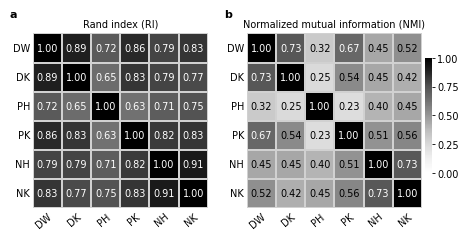

In [4]:
FIG_DPI = 600
FIG_FONT_PT = 7
FIG_PANEL_PT = 8
FIG3_WIDTH_PX = 2764
FIG3_PREVIOUS_HEIGHT_PX = 1643
FIG3_TOP_TRIM_PX = 100
FIG3_BOTTOM_TRIM_PX = 130
FIG3_HEIGHT_PX = 1413
assert FIG3_HEIGHT_PX == FIG3_PREVIOUS_HEIGHT_PX - FIG3_TOP_TRIM_PX - FIG3_BOTTOM_TRIM_PX
fig = plt.figure(
    figsize=(FIG3_WIDTH_PX / FIG_DPI, FIG3_HEIGHT_PX / FIG_DPI),
    facecolor='white',
)
heatmap_bottom = (0.18 * FIG3_PREVIOUS_HEIGHT_PX - FIG3_BOTTOM_TRIM_PX) / FIG3_HEIGHT_PX
heatmap_height = 0.64 * FIG3_PREVIOUS_HEIGHT_PX / FIG3_HEIGHT_PX
colorbar_bottom = (0.31 * FIG3_PREVIOUS_HEIGHT_PX - FIG3_BOTTOM_TRIM_PX) / FIG3_HEIGHT_PX
colorbar_height = 0.42 * FIG3_PREVIOUS_HEIGHT_PX / FIG3_HEIGHT_PX
axes = [
    fig.add_axes([0.06, heatmap_bottom, 0.38, heatmap_height]),
    fig.add_axes([0.525, heatmap_bottom, 0.38, heatmap_height]),
]
colorbar_axis = fig.add_axes([0.912, colorbar_bottom, 0.014, colorbar_height])
for panel_index, (metric_name, title) in enumerate([('RI', 'Rand index (RI)'), ('NMI', 'Normalized mutual information (NMI)')]):
    ax = axes[panel_index]
    matrix = k2_matrices[metric_name]
    sns.heatmap(
        matrix, ax=ax, cmap='Greys', vmin=0, vmax=1, square=True, annot=False,
        linewidths=0.30, linecolor='0.82', cbar=(panel_index == 1),
        cbar_ax=colorbar_axis if panel_index == 1 else None,
        cbar_kws={'ticks': [0, 0.25, 0.50, 0.75, 1.00]},
    )
    ax.set_box_aspect(1)
    ax.set_title(title, fontsize=FIG_FONT_PT, pad=5)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', length=0, labelsize=FIG_FONT_PT, pad=2)
    ax.set_xticklabels(K2_LABELS, rotation=40, ha='right', rotation_mode='anchor')
    ax.set_yticklabels(K2_LABELS, rotation=0)
    ax.text(-0.13, 1.08, 'ab'[panel_index], transform=ax.transAxes, fontsize=FIG_PANEL_PT,
            fontweight='bold', ha='left', va='bottom')
    for row in range(6):
        for column in range(6):
            value = float(matrix.iloc[row, column])
            ax.text(column + 0.5, row + 0.5, f'{value:.2f}', ha='center', va='center',
                    fontsize=FIG_FONT_PT, color='white' if value >= 0.58 else 'black')
colorbar_axis.tick_params(labelsize=FIG_FONT_PT, length=2, width=0.6, pad=2)
fig.canvas.draw()
for ax in axes:
    axis_box = ax.get_window_extent()
    assert abs(axis_box.width - axis_box.height) < 1.0

book_fig3_png = FIGURE_DIR / 'Book_Chapter_Fig_3.png'
book_fig3_tiff = FIGURE_DIR / 'Book_Chapter_Fig_3.tiff'
fig.savefig(book_fig3_png, dpi=FIG_DPI, facecolor='white')
fig.savefig(book_fig3_tiff, dpi=FIG_DPI, facecolor='white', pil_kwargs={'compression': 'tiff_lzw'})
with Image.open(book_fig3_png) as png_image:
    png_size, png_dpi = png_image.size, png_image.info.get('dpi')
with Image.open(book_fig3_tiff) as tiff_image:
    tiff_size = tiff_image.size
    tiff_dpi = tiff_image.info.get('dpi')
    tiff_compression = tiff_image.info.get('compression')
assert png_size == tiff_size == (FIG3_WIDTH_PX, FIG3_HEIGHT_PX)
assert png_dpi and all(abs(value - FIG_DPI) < 0.1 for value in png_dpi)
assert tiff_dpi and all(abs(value - FIG_DPI) < 0.1 for value in tiff_dpi)
assert str(tiff_compression).lower() in {'tiff_lzw', 'lzw'}
print(f'Saved 600-dpi PNG: {book_fig3_png}')
print(f'Saved 600-dpi LZW TIFF: {book_fig3_tiff}')
plt.show()


## Primary k = 2: strict five-stream consensus and majority assignment

The strict five-stream consensus order is DW, DK, PK, NH, NK. PH is excluded only from this consensus because of PCA-Ward dimensional sensitivity. Raw consensus patterns use untouched local labels. The fixed PK vote orientation appears only in derived vote columns; it never alters `K2_PK` or any other production assignment.

In [5]:
k2_consensus = k2_assignments.copy(deep=True)
raw_assignments_before_votes = k2_consensus[K2_COLUMNS].copy(deep=True)
k2_consensus['K2_Strict_Signature'] = k2_consensus.apply(
    lambda row: f"K2-DW{row['K2_DW']}-DK{row['K2_DK']}-PK{row['K2_PK']}-NH{row['K2_NH']}-NK{row['K2_NK']}", axis=1
)
k2_signature_summary = (
    k2_consensus['K2_Strict_Signature'].value_counts().rename_axis('K2_Strict_Signature')
    .reset_index(name='Count').sort_values(['Count', 'K2_Strict_Signature'], ascending=[False, True], ignore_index=True)
)
k2_signature_summary.insert(0, 'Rank', np.arange(1, len(k2_signature_summary) + 1))
k2_signature_summary['Proportion'] = k2_signature_summary['Count'] / 108
k2_signature_summary['Cumulative_Count'] = k2_signature_summary['Count'].cumsum()
k2_signature_summary['Cumulative_Proportion'] = k2_signature_summary['Cumulative_Count'] / 108
assert len(k2_signature_summary) == 13
top_k2_counts = dict(zip(k2_signature_summary['K2_Strict_Signature'], k2_signature_summary['Count']))
assert top_k2_counts['K2-DW2-DK2-PK1-NH2-NK2'] == 59
assert top_k2_counts['K2-DW1-DK1-PK2-NH1-NK1'] == 29
assert int(k2_signature_summary.iloc[:2]['Count'].sum()) == 88
k2_signature_summary.to_csv(PROCESSED_DIR / 'k2_raw_signature_summary.csv', index=False)

k2_consensus['K2_DW_Vote'] = k2_consensus['K2_DW']
k2_consensus['K2_DK_Vote'] = k2_consensus['K2_DK']
k2_consensus['K2_PK_Vote'] = 3 - k2_consensus['K2_PK']
k2_consensus['K2_NH_Vote'] = k2_consensus['K2_NH']
k2_consensus['K2_NK_Vote'] = k2_consensus['K2_NK']
pd.testing.assert_frame_equal(k2_consensus[K2_COLUMNS], raw_assignments_before_votes)
vote_columns = ['K2_DW_Vote', 'K2_DK_Vote', 'K2_PK_Vote', 'K2_NH_Vote', 'K2_NK_Vote']
for column in vote_columns:
    assert set(k2_consensus[column]) == {1, 2}
k2_consensus['K2_Vote_Count_1'] = k2_consensus[vote_columns].eq(1).sum(axis=1)
k2_consensus['K2_Vote_Count_2'] = k2_consensus[vote_columns].eq(2).sum(axis=1)
assert (k2_consensus['K2_Vote_Count_1'] + k2_consensus['K2_Vote_Count_2'] == 5).all()
k2_consensus['K2_Consensus_Side'] = np.where(
    k2_consensus['K2_Vote_Count_1'] > k2_consensus['K2_Vote_Count_2'], 1, 2
)
k2_consensus['K2_Consensus_Count'] = k2_consensus[['K2_Vote_Count_1', 'K2_Vote_Count_2']].max(axis=1)
k2_consensus['K2_Consensus_Fraction'] = k2_consensus['K2_Consensus_Count'] / 5
strength_counts = k2_consensus['K2_Consensus_Count'].value_counts().to_dict()
assert strength_counts == {5: 88, 4: 10, 3: 10}
assert int((k2_consensus['K2_Consensus_Count'] >= 4).sum()) == 98

vote_labels = dict(zip(vote_columns, K2_CONSENSUS_LABELS))
def dissenting_pipeline(row):
    if row['K2_Consensus_Count'] != 4:
        return pd.NA
    return next(vote_labels[column] for column in vote_columns if row[column] != row['K2_Consensus_Side'])
def minority_pair(row):
    if row['K2_Consensus_Count'] != 3:
        return pd.NA
    return ' + '.join(vote_labels[column] for column in vote_columns if row[column] != row['K2_Consensus_Side'])

k2_consensus['K2_Dissenting_Pipeline'] = k2_consensus.apply(dissenting_pipeline, axis=1)
k2_consensus['K2_Minority_Pipeline_Pair'] = k2_consensus.apply(minority_pair, axis=1)
k2_consensus['K2_Majority_Group'] = k2_consensus['K2_Consensus_Side'].map({1: 'K2_M1', 2: 'K2_M2'})
k2_consensus['K2_Unanimous_Group'] = pd.Series(pd.NA, index=k2_consensus.index, dtype='string')
unanimous_mask = k2_consensus['K2_Consensus_Count'].eq(5)
k2_consensus.loc[unanimous_mask, 'K2_Unanimous_Group'] = (
    k2_consensus.loc[unanimous_mask, 'K2_Consensus_Side'].map({1: 'K2_U1', 2: 'K2_U2'})
)
assert k2_consensus['K2_Unanimous_Group'].value_counts().to_dict() == {'K2_U2': 59, 'K2_U1': 29}
assert k2_consensus['K2_Majority_Group'].value_counts().to_dict() == {'K2_M2': 69, 'K2_M1': 39}
unanimous_signatures = k2_consensus.loc[unanimous_mask].groupby('K2_Unanimous_Group')['K2_Strict_Signature'].unique().to_dict()
assert unanimous_signatures['K2_U1'].tolist() == ['K2-DW1-DK1-PK2-NH1-NK1']
assert unanimous_signatures['K2_U2'].tolist() == ['K2-DW2-DK2-PK1-NH2-NK2']
majority_breakdown = pd.crosstab(k2_consensus['K2_Majority_Group'], k2_consensus['K2_Consensus_Count']).reindex(
    index=['K2_M1', 'K2_M2'], columns=[5, 4, 3], fill_value=0
)
np.testing.assert_array_equal(majority_breakdown.to_numpy(), np.array([[29, 3, 7], [59, 7, 3]]))
dissenter_counts = k2_consensus['K2_Dissenting_Pipeline'].value_counts().reindex(K2_CONSENSUS_LABELS, fill_value=0).to_dict()
assert dissenter_counts == {'DW': 1, 'DK': 3, 'PK': 3, 'NH': 2, 'NK': 1}
minority_pair_counts = k2_consensus['K2_Minority_Pipeline_Pair'].value_counts().to_dict()
assert minority_pair_counts == {'NH + NK': 5, 'DW + DK': 3, 'DW + NK': 1, 'DK + NH': 1}

k2_output_columns = [
    'Cell_Name', *K2_COLUMNS, 'K2_Strict_Signature', *vote_columns,
    'K2_Vote_Count_1', 'K2_Vote_Count_2', 'K2_Consensus_Side', 'K2_Consensus_Count',
    'K2_Consensus_Fraction', 'K2_Dissenting_Pipeline', 'K2_Minority_Pipeline_Pair',
    'K2_Majority_Group', 'K2_Unanimous_Group',
]
k2_consensus_output = k2_consensus[k2_output_columns].copy()
allowed_missing = {'K2_Dissenting_Pipeline', 'K2_Minority_Pipeline_Pair', 'K2_Unanimous_Group'}
assert not k2_consensus_output[[c for c in k2_output_columns if c not in allowed_missing]].isna().any().any()
assert len(k2_consensus_output) == 108 and k2_consensus_output['Cell_Name'].is_unique
assert k2_consensus_output['Cell_Name'].tolist() == reference_cells
k2_consensus_output.to_csv(PROCESSED_DIR / 'k2_consensus_assignments.csv', index=False)
k2_unanimous_columns = ['Cell_Name', 'K2_DW', 'K2_DK', 'K2_PK', 'K2_NH', 'K2_NK', 'K2_Strict_Signature', 'K2_Unanimous_Group']
k2_unanimous_output = k2_consensus.loc[unanimous_mask, k2_unanimous_columns].copy()
assert len(k2_unanimous_output) == 88 and k2_unanimous_output['Cell_Name'].is_unique
k2_unanimous_output.to_csv(PROCESSED_DIR / 'k2_unanimous_consensus_cells.csv', index=False)

display(k2_signature_summary.head(5))
display(majority_breakdown)
print(f'Consensus strength: 5/5={strength_counts[5]}, 4/5={strength_counts[4]}, 3/5={strength_counts[3]}, >=4/5=98')
print(f'Unanimous: K2_U1=29, K2_U2=59; majority: K2_M1=39, K2_M2=69')
print(f'Dissenters: {dissenter_counts}')
print(f'Minority pairs: {minority_pair_counts}')


,Rank,K2_Strict_Signature,Count,Proportion,Cumulative_Count,Cumulative_Proportion
0,1,K2-DW2-DK2-PK1-NH2-NK2,59,0.546296,59,0.546296
1,2,K2-DW1-DK1-PK2-NH1-NK1,29,0.268519,88,0.814815
2,3,K2-DW1-DK1-PK2-NH2-NK2,3,0.027778,91,0.842593
3,4,K2-DW2-DK1-PK1-NH2-NK2,3,0.027778,94,0.870370
4,5,K2-DW2-DK2-PK2-NH1-NK1,3,0.027778,97,0.898148


K2_Consensus_Count,5,4,3
K2_Majority_Group,,,
K2_M1,29,3,7
K2_M2,59,7,3


Consensus strength: 5/5=88, 4/5=10, 3/5=10, >=4/5=98
Unanimous: K2_U1=29, K2_U2=59; majority: K2_M1=39, K2_M2=69
Dissenters: {'DW': 1, 'DK': 3, 'PK': 3, 'NH': 2, 'NK': 1}
Minority pairs: {'NH + NK': 5, 'DW + DK': 3, 'DW + NK': 1, 'DK + NH': 1}


## Secondary k = 3: complete six-stream audit and stability-qualified strict five-stream set

The complete finer-resolution audit uses DW, DK, PH, PK, NH, and NK in that fixed order and computes RI, NMI, and ARI directly from untouched pipeline-local labels. The stability-qualified strict five-stream set uses DW-DK-PK-NH-NK in exactly that order. DK remains eligible because its seed-stability validation is strong; PH remains visible in the complete audit but is excluded from exact signatures because the 12–14-PC validation shows material PCA-Ward dimensional sensitivity. This role qualification is based on method stability, not on selecting streams that happen to agree most strongly.

k=3 RI:


,DW,DK,PH,PK,NH,NK
Pipeline,,,,,,
DW,1.000000,0.763240,0.601073,0.648321,0.671166,0.706127
DK,0.763240,1.000000,0.598996,0.722049,0.686051,0.700935
PH,0.601073,0.598996,1.000000,0.642264,0.679301,0.663032
PK,0.648321,0.722049,0.642264,1.000000,0.673936,0.676705
NH,0.671166,0.686051,0.679301,0.673936,1.000000,0.843544
NK,0.706127,0.700935,0.663032,0.676705,0.843544,1.000000


k=3 NMI:


,DW,DK,PH,PK,NH,NK
Pipeline,,,,,,
DW,1.000000,0.618878,0.260149,0.362025,0.333927,0.407368
DK,0.618878,1.000000,0.252380,0.378643,0.340347,0.392262
PH,0.260149,0.252380,1.000000,0.358732,0.419738,0.339965
PK,0.362025,0.378643,0.358732,1.000000,0.374528,0.389345
NH,0.333927,0.340347,0.419738,0.374528,1.000000,0.603170
NK,0.407368,0.392262,0.339965,0.389345,0.603170,1.000000


k=3 ARI:


,DW,DK,PH,PK,NH,NK
Pipeline,,,,,,
DW,1.000000,0.480327,0.144228,0.252216,0.268231,0.346030
DK,0.480327,1.000000,0.138451,0.408196,0.299686,0.332887
PH,0.144228,0.138451,1.000000,0.249847,0.303735,0.268415
PK,0.252216,0.408196,0.249847,1.000000,0.299409,0.305359
NH,0.268231,0.299686,0.303735,0.299409,1.000000,0.645264
NK,0.346030,0.332887,0.268415,0.305359,0.645264,1.000000


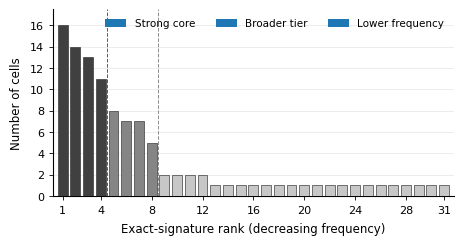

,Rank,K3_Strict_Signature,K3_DW,K3_DK,K3_PK,K3_NH,K3_NK,Num_Cells,Proportion,Cumulative_Cells,Cumulative_Proportion,Tier
0,1,K3-DW2a-DK0-PK1-NH2-NK3,2a,0,1,2,3,16,0.148148,16,0.148148,Strong core
1,2,K3-DW1-DK1-PK2-NH1-NK1,1,1,2,1,1,14,0.129630,30,0.277778,Strong core
2,3,K3-DW1-DK1-PK3-NH1-NK1,1,1,3,1,1,13,0.120370,43,0.398148,Strong core
3,4,K3-DW2b-DK0-PK1-NH3-NK2,2b,0,1,3,2,11,0.101852,54,0.500000,Strong core
4,5,K3-DW2a-DK0-PK1-NH3-NK2,2a,0,1,3,2,8,0.074074,62,0.574074,Broader tier
5,6,K3-DW2b-DK0-PK1-NH2-NK3,2b,0,1,2,3,7,0.064815,69,0.638889,Broader tier
6,7,K3-DW2b-DK2-PK1-NH2-NK3,2b,2,1,2,3,7,0.064815,76,0.703704,Broader tier
7,8,K3-DW2b-DK2-PK3-NH3-NK2,2b,2,3,3,2,5,0.046296,81,0.750000,Broader tier
8,9,K3-DW1-DK1-PK3-NH3-NK2,1,1,3,3,2,2,0.018519,83,0.768519,Lower frequency
9,10,K3-DW2b-DK2-PK1-NH1-NK2,2b,2,1,1,2,2,0.018519,85,0.787037,Lower frequency


k=3 complete audit order: DW DK PH PK NH NK; RI/NMI/ARI are 6x6.
k=3 strict signature order: DW DK PK NH NK; pipeline-local labels remain untouched.
Exact signatures: 31 total; 19 singletons; median size=1.
Strong core: 4 signatures / 54 cells (50.0%).
Broader tier: 8 signatures / 81 cells (75.0%).


In [6]:
k3_matrices = agreement_matrices(k3_assignments, K3_COLUMNS, K3_LABELS)
expected_k3 = {
    'RI': np.array([
        [1.0, 0.7632398753894081, 0.6010730356524749, 0.6483212184146764, 0.6711664935964001, 0.7061266874350987],
        [0.7632398753894081, 1.0, 0.5989961924541364, 0.7220491519556940, 0.6860505365178262, 0.7009345794392523],
        [0.6010730356524749, 0.5989961924541364, 1.0, 0.6422637590861890, 0.6793007961232260, 0.6630321910695742],
        [0.6483212184146764, 0.7220491519556940, 0.6422637590861890, 1.0, 0.6739356178608515, 0.6767047421253028],
        [0.6711664935964001, 0.6860505365178262, 0.6793007961232260, 0.6739356178608515, 1.0, 0.8435444790584977],
        [0.7061266874350987, 0.7009345794392523, 0.6630321910695742, 0.6767047421253028, 0.8435444790584977, 1.0],
    ]),
    'NMI': np.array([
        [1.0, 0.6188782194424759, 0.2601490683692965, 0.36202463470285845, 0.33392738126476584, 0.4073681663601227],
        [0.6188782194424759, 1.0, 0.25238018500546266, 0.3786427386390017, 0.34034691264741984, 0.3922617400401375],
        [0.2601490683692965, 0.2523801850054627, 1.0, 0.3587322912818631, 0.41973829577629324, 0.3399653176157138],
        [0.36202463470285845, 0.37864273863900166, 0.3587322912818632, 1.0, 0.37452781608618674, 0.3893447695282580],
        [0.3339273812647658, 0.34034691264741984, 0.41973829577629324, 0.37452781608618674, 1.0, 0.6031700728031621],
        [0.4073681663601227, 0.3922617400401375, 0.3399653176157138, 0.38934476952825803, 0.6031700728031621, 1.0],
    ]),
    'ARI': np.array([
        [1.0, 0.48032742846525894, 0.1442277109200155, 0.25221576272566043, 0.2682309361900736, 0.3460295419214447],
        [0.48032742846525894, 1.0, 0.13845118437955747, 0.4081957596580910, 0.2996860601653205, 0.3328872723074277],
        [0.1442277109200155, 0.13845118437955747, 1.0, 0.24984652259198753, 0.3037354533482905, 0.2684149636638541],
        [0.25221576272566043, 0.4081957596580910, 0.24984652259198753, 1.0, 0.29940891831704486, 0.3053587364205094],
        [0.2682309361900736, 0.2996860601653205, 0.3037354533482905, 0.29940891831704486, 1.0, 0.6452642172094780],
        [0.3460295419214447, 0.3328872723074277, 0.2684149636638541, 0.3053587364205094, 0.6452642172094780, 1.0],
    ]),
}
for metric_name, matrix in k3_matrices.items():
    np.testing.assert_allclose(matrix.to_numpy(), expected_k3[metric_name], rtol=0, atol=1e-12)
    matrix.to_csv(PROCESSED_DIR / f'k3_cluster_agreement_{metric_name.lower()}_matrix.csv', index_label='Pipeline')
    print(f'k=3 {metric_name}:')
    display(matrix.round(6))

anchor_targets = {
    ('DW', 'DK'): {'RI': 0.7632398753894081, 'NMI': 0.6188782194424759, 'ARI': 0.48032742846525894},
    ('PH', 'PK'): {'RI': 0.6422637590861890, 'NMI': 0.3587322912818631},
}
for pair, targets in anchor_targets.items():
    for metric_name, target in targets.items():
        observed = k3_matrices[metric_name].loc[pair[0], pair[1]]
        assert np.isclose(observed, target, rtol=0, atol=1e-12)

k3_signature_cells = k3_assignments.copy(deep=True)
k3_assignments_before_signatures = k3_signature_cells[K3_COLUMNS].copy(deep=True)
k3_signature_cells['K3_Strict_Signature'] = k3_signature_cells.apply(
    lambda row: (
        f"K3-DW{row['K3_DW']}-DK{row['K3_DK']}-PK{row['K3_PK']}"
        f"-NH{row['K3_NH']}-NK{row['K3_NK']}"
    ),
    axis=1,
)
pd.testing.assert_frame_equal(k3_signature_cells[K3_COLUMNS], k3_assignments_before_signatures)

k3_signature_components = k3_signature_cells.drop_duplicates('K3_Strict_Signature')[
    ['K3_Strict_Signature', *K3_STRICT_COLUMNS]
]
k3_signature_summary = (
    k3_signature_cells['K3_Strict_Signature'].value_counts()
    .rename_axis('K3_Strict_Signature').reset_index(name='Num_Cells')
    .merge(k3_signature_components, on='K3_Strict_Signature', validate='one_to_one')
    .sort_values(['Num_Cells', 'K3_Strict_Signature'], ascending=[False, True], ignore_index=True)
)
k3_signature_summary.insert(0, 'Rank', np.arange(1, len(k3_signature_summary) + 1))
k3_signature_summary['Proportion'] = k3_signature_summary['Num_Cells'] / 108
k3_signature_summary['Cumulative_Cells'] = k3_signature_summary['Num_Cells'].cumsum()
k3_signature_summary['Cumulative_Proportion'] = k3_signature_summary['Cumulative_Cells'] / 108
k3_signature_summary['Tier'] = np.select(
    [k3_signature_summary['Num_Cells'].ge(10), k3_signature_summary['Num_Cells'].ge(5)],
    ['Strong core', 'Broader tier'],
    default='Lower frequency',
)
k3_summary_columns = [
    'Rank', 'K3_Strict_Signature', *K3_STRICT_COLUMNS, 'Num_Cells', 'Proportion',
    'Cumulative_Cells', 'Cumulative_Proportion', 'Tier',
]
k3_signature_summary = k3_signature_summary[k3_summary_columns]

expected_frequency_sequence = [16, 14, 13, 11, 8, 7, 7, 5, 2, 2, 2, 2, *([1] * 19)]
assert k3_signature_summary['Num_Cells'].tolist() == expected_frequency_sequence
assert len(k3_signature_summary) == 31
assert int(k3_signature_summary['Num_Cells'].sum()) == 108
assert int((k3_signature_summary['Num_Cells'] == 1).sum()) == 19
assert float(k3_signature_summary['Num_Cells'].median()) == 1.0
assert not k3_signature_summary['Num_Cells'].isin([3, 4]).any()

expected_top_signatures = {
    'K3-DW2a-DK0-PK1-NH2-NK3': 16,
    'K3-DW1-DK1-PK2-NH1-NK1': 14,
    'K3-DW1-DK1-PK3-NH1-NK1': 13,
    'K3-DW2b-DK0-PK1-NH3-NK2': 11,
}
assert dict(zip(
    k3_signature_summary.iloc[:4]['K3_Strict_Signature'],
    k3_signature_summary.iloc[:4]['Num_Cells'],
)) == expected_top_signatures

threshold_validation = {
    10: (4, 54),
    5: (8, 81),
    3: (8, 81),
    2: (12, 89),
}
for threshold, (expected_signatures, expected_cells) in threshold_validation.items():
    selected = k3_signature_summary['Num_Cells'].ge(threshold)
    assert int(selected.sum()) == expected_signatures
    assert int(k3_signature_summary.loc[selected, 'Num_Cells'].sum()) == expected_cells

rank_map = k3_signature_summary.set_index('K3_Strict_Signature')['Rank']
count_map = k3_signature_summary.set_index('K3_Strict_Signature')['Num_Cells']
tier_map = k3_signature_summary.set_index('K3_Strict_Signature')['Tier']
k3_signature_cells['Signature_Rank'] = k3_signature_cells['K3_Strict_Signature'].map(rank_map)
k3_signature_cells['Signature_N'] = k3_signature_cells['K3_Strict_Signature'].map(count_map)
k3_signature_cells['Tier'] = k3_signature_cells['K3_Strict_Signature'].map(tier_map)
k3_all_cell_columns = [
    'Cell_Name', *K3_COLUMNS, 'K3_Strict_Signature', 'Signature_Rank', 'Signature_N', 'Tier',
]
k3_all_cell_output = k3_signature_cells[k3_all_cell_columns].copy()
assert k3_all_cell_output.shape == (108, 11)
assert k3_all_cell_output['Cell_Name'].is_unique
assert k3_all_cell_output['Cell_Name'].tolist() == reference_cells
assert not k3_all_cell_output.isna().any().any()

k3_strong_core = k3_all_cell_output.loc[k3_all_cell_output['Signature_N'].ge(10)].copy()
k3_broader_tier = k3_all_cell_output.loc[k3_all_cell_output['Signature_N'].ge(5)].copy()
assert len(k3_strong_core) == 54 and len(k3_broader_tier) == 81
assert k3_strong_core['Cell_Name'].is_unique and k3_broader_tier['Cell_Name'].is_unique
assert set(k3_strong_core['Cell_Name']) < set(k3_broader_tier['Cell_Name'])
assert k3_strong_core['Cell_Name'].tolist() == [cell for cell in reference_cells if cell in set(k3_strong_core['Cell_Name'])]
assert k3_broader_tier['Cell_Name'].tolist() == [cell for cell in reference_cells if cell in set(k3_broader_tier['Cell_Name'])]

K3_SUMMARY_PATH = PROCESSED_DIR / 'k3_stability_qualified_signature_summary.csv'
K3_ALL_CELL_PATH = PROCESSED_DIR / 'k3_cluster_assignments_with_stability_qualified_signatures.csv'
K3_STRONG_CORE_PATH = PROCESSED_DIR / 'k3_strong_core_signature_cells.csv'
K3_BROADER_TIER_PATH = PROCESSED_DIR / 'k3_broader_tier_signature_cells.csv'
k3_signature_summary.to_csv(K3_SUMMARY_PATH, index=False)
k3_all_cell_output.to_csv(K3_ALL_CELL_PATH, index=False)
k3_strong_core.to_csv(K3_STRONG_CORE_PATH, index=False)
k3_broader_tier.to_csv(K3_BROADER_TIER_PATH, index=False)

K3_FREQUENCY_FIGURE_PATH = FIGURE_DIR / 'k3_stability_qualified_signature_frequency_distribution.png'
tier_colors = {'Strong core': '0.25', 'Broader tier': '0.52', 'Lower frequency': '0.78'}
bar_colors = k3_signature_summary['Tier'].map(tier_colors)
fig, ax = plt.subplots(figsize=(119 / 25.4, 65 / 25.4), facecolor='white')
ax.set_axisbelow(True)
ax.bar(
    k3_signature_summary['Rank'], k3_signature_summary['Num_Cells'], width=0.78,
    color=bar_colors, edgecolor='0.18', linewidth=0.45, zorder=3,
)
for tier in ['Strong core', 'Broader tier', 'Lower frequency']:
    ax.bar([], [], color=tier_colors[tier], edgecolor='0.18', linewidth=0.45, label=tier)
ax.axvline(4.5, color='0.35', linewidth=0.7, linestyle='--')
ax.axvline(8.5, color='0.55', linewidth=0.7, linestyle='--')
ax.set_xlim(0.25, 31.75)
ax.set_ylim(0, 17.5)
ax.set_xticks([1, 4, 8, 12, 16, 20, 24, 28, 31])
ax.set_yticks(np.arange(0, 18, 2))
ax.set_xlabel('Exact-signature rank (decreasing frequency)', fontsize=8.5, labelpad=5)
ax.set_ylabel('Number of cells', fontsize=8.5, labelpad=5)
ax.tick_params(axis='both', labelsize=8, width=0.6, length=3)
ax.yaxis.grid(True, color='0.90', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=7.5, ncol=3, loc='upper right')
fig.subplots_adjust(left=0.13, right=0.985, bottom=0.22, top=0.95)
fig.savefig(K3_FREQUENCY_FIGURE_PATH, dpi=300, facecolor='white')
plt.show()

display(k3_signature_summary.head(12))
print('k=3 complete audit order: DW DK PH PK NH NK; RI/NMI/ARI are 6x6.')
print('k=3 strict signature order: DW DK PK NH NK; pipeline-local labels remain untouched.')
print('Exact signatures: 31 total; 19 singletons; median size=1.')
print('Strong core: 4 signatures / 54 cells (50.0%).')
print('Broader tier: 8 signatures / 81 cells (75.0%).')

## Validation and outputs

The production outputs comprise the primary k = 2 agreement matrices, strict five-stream consensus and majority assignment, the complete six-stream k = 3 agreement matrices, and the stability-qualified strict five-stream exact-signature interfaces. The strong recurrent core and broader recurrent tier thresholds describe the observed frequency distribution; lower-frequency exact signatures remain valid descriptive assignments outside those tiers.

**Provenance note.** Superseded S1–S5 / 57-cell artifacts are not production inputs and are not accessed by this notebook.

In [7]:
expected_outputs = [
    *(PROCESSED_DIR / f'k2_cluster_agreement_{metric}_matrix.csv' for metric in ['ri', 'nmi', 'ari']),
    PROCESSED_DIR / 'k2_raw_signature_summary.csv',
    PROCESSED_DIR / 'k2_consensus_assignments.csv',
    PROCESSED_DIR / 'k2_unanimous_consensus_cells.csv',
    *(PROCESSED_DIR / f'k3_cluster_agreement_{metric}_matrix.csv' for metric in ['ri', 'nmi', 'ari']),
    K3_SUMMARY_PATH, K3_ALL_CELL_PATH, K3_STRONG_CORE_PATH, K3_BROADER_TIER_PATH,
    book_fig3_png, book_fig3_tiff, K3_FREQUENCY_FIGURE_PATH,
]
assert all(path.exists() and path.stat().st_size > 0 for path in expected_outputs)

assert pd.read_csv(K3_SUMMARY_PATH).columns.tolist() == k3_summary_columns
assert pd.read_csv(K3_SUMMARY_PATH).shape == (31, 12)
assert pd.read_csv(K3_ALL_CELL_PATH).columns.tolist() == k3_all_cell_columns
assert pd.read_csv(K3_ALL_CELL_PATH).shape == (108, 11)
assert pd.read_csv(K3_STRONG_CORE_PATH).columns.tolist() == k3_all_cell_columns
assert pd.read_csv(K3_STRONG_CORE_PATH).shape == (54, 11)
assert pd.read_csv(K3_BROADER_TIER_PATH).columns.tolist() == k3_all_cell_columns
assert pd.read_csv(K3_BROADER_TIER_PATH).shape == (81, 11)

with Image.open(book_fig3_png) as image:
    fig3_png_size = image.size
    fig3_png_dpi = image.info.get('dpi')
with Image.open(book_fig3_tiff) as image:
    fig3_tiff_size = image.size
    fig3_tiff_dpi = image.info.get('dpi')
    fig3_tiff_compression = image.info.get('compression')
with Image.open(K3_FREQUENCY_FIGURE_PATH) as image:
    k3_frequency_size = image.size
    k3_frequency_dpi = image.info.get('dpi')
assert fig3_png_size == fig3_tiff_size == (FIG3_WIDTH_PX, FIG3_HEIGHT_PX)
assert all(abs(value - 600) < 0.1 for value in fig3_png_dpi)
assert all(abs(value - 600) < 0.1 for value in fig3_tiff_dpi)
assert fig3_tiff_compression == 'tiff_lzw'
assert k3_frequency_size[0] > 0 and k3_frequency_size[1] > 0
assert k3_frequency_dpi and all(abs(value - 300) < 0.1 for value in k3_frequency_dpi)

print('FINAL VALIDATION: ALL CHECKS PASSED')
print('Inputs: six exact schemas; each 108 rows/108 unique cells; identical order; no missing assignments.')
print('k=2 audit order: DW DK PH PK NH NK; all locked metrics and consensus assertions PASS.')
print('k=2 consensus: signatures=13; 5/5=88; >=4/5=98; all 108 receive a majority.')
print('k=2 groups: K2_U1=29, K2_U2=59, K2_M1=39, K2_M2=69.')
print('k=3 complete audit: DW DK PH PK NH NK; RI/NMI/ARI each 6x6.')
print('k=3 strict order: DW DK PK NH NK; exact signatures=31; singletons=19; median size=1.')
print('k=3 strong core=4 signatures/54 cells; broader tier=8 signatures/81 cells.')
print('Threshold validation: N>=3 gives 8/81; N>=2 gives 12/89; no size-3 or size-4 signatures.')
print('Historical S1–S5 artifacts are not production inputs and are not accessed by this notebook.')
print(f'Figure 3: {fig3_png_size} px; PNG/TIFF 600 dpi; TIFF compression={fig3_tiff_compression}.')
print(f'New supporting k=3 frequency figure: {k3_frequency_size} px at approximately 300 dpi.')

FINAL VALIDATION: ALL CHECKS PASSED
Inputs: six exact schemas; each 108 rows/108 unique cells; identical order; no missing assignments.
k=2 audit order: DW DK PH PK NH NK; all locked metrics and consensus assertions PASS.
k=2 consensus: signatures=13; 5/5=88; >=4/5=98; all 108 receive a majority.
k=2 groups: K2_U1=29, K2_U2=59, K2_M1=39, K2_M2=69.
k=3 complete audit: DW DK PH PK NH NK; RI/NMI/ARI each 6x6.
k=3 strict order: DW DK PK NH NK; exact signatures=31; singletons=19; median size=1.
k=3 strong core=4 signatures/54 cells; broader tier=8 signatures/81 cells.
Threshold validation: N>=3 gives 8/81; N>=2 gives 12/89; no size-3 or size-4 signatures.
Historical S1–S5 artifacts are not production inputs and are not accessed by this notebook.
Figure 3: (2764, 1413) px; PNG/TIFF 600 dpi; TIFF compression=tiff_lzw.
New supporting k=3 frequency figure: (1405, 767) px at approximately 300 dpi.
